This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
%pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.27.1 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Timeseries forecasting

### Different kinds of timeseries tasks

### A temperature forecasting example

In [4]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-04-06 22:12:20--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.252.50, 52.217.67.126, 16.15.207.21, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.252.50|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  22.8MB/s    in 0.6s    

2026-04-06 22:12:21 (22.8 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [5]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [6]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

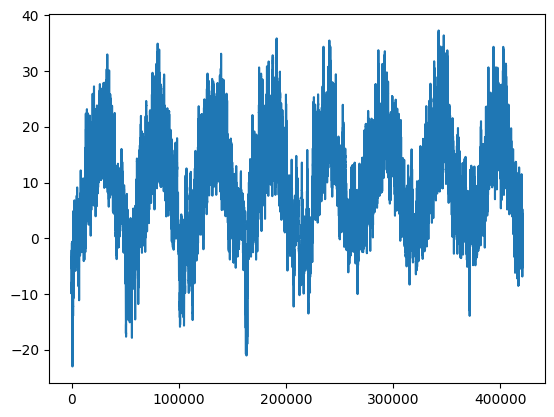

In [7]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

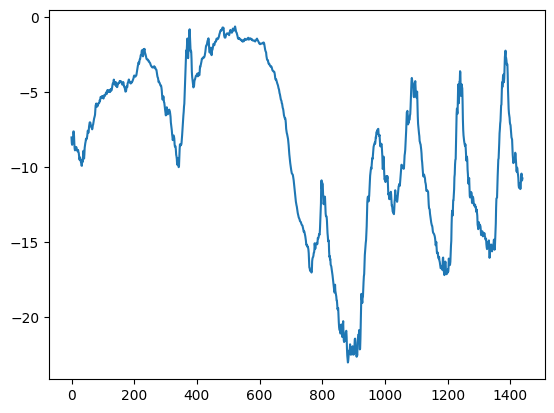

In [8]:
plt.plot(range(1440), temperature[:1440])

In [9]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


#### Preparing the data

In [10]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [11]:
import numpy as np
import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [12]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [13]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


#### A commonsense, non-machine-learning baseline

In [14]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


#### Let's try a basic machine learning model

In [15]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - loss: 13.8510 - mae: 2.8257 - val_loss: 10.5986 - val_mae: 2.5669
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 8.3109 - mae: 2.2716 - val_loss: 11.2488 - val_mae: 2.6482
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 7.4241 - mae: 2.1479 - val_loss: 10.7037 - val_mae: 2.5874
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 6.9898 - mae: 2.0853 - val_loss: 10.9744 - val_mae: 2.6289
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 6.6600 - mae: 2.0382 - val_loss: 11.4262 - val_mae: 2.6700
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 6.4357 - mae: 2.0036 - val_loss: 11.2183 - val_mae: 2.6460
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - loss: 6.2469 - mae: 1.9756 - val_loss: 11.5120 - val_mae: 2.6744
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 6.1237 - mae: 1.9546 - val_loss: 11.6082 - val_mae: 2.6914
Epoch 9/10
819/819 ━━━━━━━━━━━━

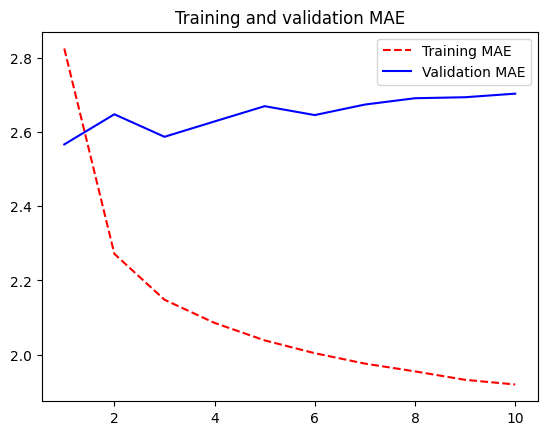

In [16]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### Let's try a 1D convolutional model

In [17]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - loss: 25.7183 - mae: 3.9470 - val_loss: 15.9781 - val_mae: 3.1571
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 15.0141 - mae: 3.0869 - val_loss: 15.1141 - val_mae: 3.0728
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 13.4420 - mae: 2.9145 - val_loss: 16.1193 - val_mae: 3.1481
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - loss: 12.4823 - mae: 2.8034 - val_loss: 15.7459 - val_mae: 3.1275
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 11.7846 - mae: 2.7243 - val_loss: 15.1120 - val_mae: 3.0628
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 11.2636 - mae: 2.6640 - val_loss: 15.2513 - val_mae: 3.0837
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 10.9033 - mae: 2.6209 - val_loss: 15.2519 - val_mae: 3.0881
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 10.5537 - mae: 2.5785 - val_loss: 15.3547 - val_mae: 3.1068
Epoch 9/10
819/819 ━━━━━

### Recurrent neural networks

In [18]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print("Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - loss: 81.9532 - mae: 7.3221 - val_loss: 64.0150 - val_mae: 6.5710
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 72.0046 - mae: 6.8763 - val_loss: 62.2768 - val_mae: 6.4883
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 68.4195 - mae: 6.7514 - val_loss: 57.7764 - val_mae: 6.2872
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 62.3029 - mae: 6.4589 - val_loss: 49.5799 - val_mae: 5.8347
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 42.4872 - mae: 5.2496 - val_loss: 24.3190 - val_mae: 3.9108
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 23.8585 - mae: 3.8480 - val_loss: 20.7845 - val_mae: 3.5236
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 22.0733 - mae: 3.6943 - val_loss: 19.8596 - val_mae: 3.4226
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 20.3941 - mae: 3.5357 - val_loss: 19.3135 - val_mae: 3.4402
Epoch 9/10
819/819 ━━━━━

#### Understanding recurrent neural networks

In [19]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.concatenate(successive_outputs, axis=0)

#### A recurrent layer in Keras

In [20]:
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

In [21]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


In [22]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


In [23]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

#### Getting the most out of recurrent neural networks

#### Using recurrent dropout to fight overfitting

In [24]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 57ms/step - loss: 31.1640 - mae: 4.1459 - val_loss: 11.2757 - val_mae: 2.5821
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 16.4496 - mae: 3.1491 - val_loss: 9.5216 - val_mae: 2.3880
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 15.1154 - mae: 3.0227 - val_loss: 9.1805 - val_mae: 2.3542
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 14.5394 - mae: 2.9650 - val_loss: 9.2878 - val_mae: 2.3696
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 14.0316 - mae: 2.9117 - val_loss: 9.1077 - val_mae: 2.3482
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 13.6268 - mae: 2.8662 - val_loss: 8.9896 - val_mae: 2.3387
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 13.2618 - mae: 2.8272 - val_loss: 8.8341 - val_mae: 2.3134
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 12.9826 - mae: 2.7983 - val_loss: 8.8241 - val_mae: 2.3104
Epoch 9/50
819/819 ━━━━━━━━━━━━

#### Stacking recurrent layers

In [26]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 62ms/step - loss: 28.5805 - mae: 3.9546 - val_loss: 10.5641 - val_mae: 2.4640
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 14.9499 - mae: 2.9829 - val_loss: 9.1818 - val_mae: 2.3349
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 14.0238 - mae: 2.8940 - val_loss: 8.9965 - val_mae: 2.3214
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 13.4320 - mae: 2.8328 - val_loss: 8.8674 - val_mae: 2.3083
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 13.0624 - mae: 2.7957 - val_loss: 8.5244 - val_mae: 2.2629
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - loss: 12.6729 - mae: 2.7586 - val_loss: 8.5784 - val_mae: 2.2720
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 12.3050 - mae: 2.7185 - val_loss: 8.6039 - val_mae: 2.2748
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 11.9459 - mae: 2.6809 - val_loss: 8.5356 - val_mae: 2.2620
Epoch 9/50
819/819 ━━━━━━━━━━━━

*italicized text*#### Using bidirectional RNNs

In [27]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 83.5371 - mae: 7.3706 - val_loss: 58.8533 - val_mae: 6.3172
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 55s 67ms/step - loss: 59.8209 - mae: 6.1788 - val_loss: 42.7475 - val_mae: 5.2473
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 52.3921 - mae: 5.7320 - val_loss: 48.3472 - val_mae: 5.6137
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 52.3383 - mae: 5.6366 - val_loss: 42.7572 - val_mae: 5.3736
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 58ms/step - loss: 36.8350 - mae: 4.6774 - val_loss: 19.1731 - val_mae: 3.4089
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 57ms/step - loss: 22.3746 - mae: 3.6170 - val_loss: 15.5731 - val_mae: 3.1436
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 19.8638 - mae: 3.4694 - val_loss: 13.9200 - val_mae: 2.9244
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 77s 93ms/step - loss: 19.0390 - mae: 3.3917 - val_loss: 14.1120 - val_mae: 2.9675
Epoch 9/10
819/819 ━━━━━